# Notebook 305 — Global Transcriptomic Structure Analysis

## Objective

This notebook characterizes the global structure of the harmonized transcriptomic cohort generated in previous integration and quality-control stages.

The primary goal is to identify the major sources of transcriptomic variation present across the integrated modeling universe and to evaluate the extent to which lineage effects dominate the observed expression landscape.

This analysis serves as a structural assessment of the transcriptomic layer before any program-discovery procedures are performed.

---

## Scientific Rationale

Transcriptomic datasets are typically organized around strong biological and technical sources of variation. In pan-cancer settings, tissue lineage is often the dominant factor shaping global expression patterns.

Before attempting to identify recurrent transcriptomic programs, it is therefore necessary to:

- characterize the overall geometry of the expression space,
- quantify the contribution of lineage-related structure,
- identify potential outliers and anomalous samples,
- evaluate whether evidence of cross-lineage organization exists,
- establish a baseline understanding of transcriptomic heterogeneity within the integrated cohort.

This notebook is exploratory and descriptive in nature. No biological programs, resistance-like phenotypes, candidate vulnerabilities, or perturbational hypotheses are inferred at this stage.

---

## Key Questions

This notebook seeks to address the following questions:

1. How is transcriptomic variation distributed across the integrated cohort?
2. To what extent does lineage explain the observed transcriptomic structure?
3. Are samples primarily organized by tissue-of-origin?
4. Do potential cross-lineage patterns emerge after dimensionality reduction?
5. Are there transcriptomic outliers or unexpected cohort structures that require further investigation?

---

## Expected Outputs

The analyses performed in this notebook will generate:

- Principal Component Analysis (PCA) embeddings
- Explained variance summaries
- UMAP visualizations
- Exploratory clustering assessments
- Lineage-aware structure evaluations
- Transcriptomic structure summary metrics

These outputs will provide the foundation for downstream program-discovery analyses.

---

In [1]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import Paths

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import umap.umap_ as umap

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
# =============================================================================
# Load harmonized expression matrix
# =============================================================================

PROJECT_ROOT = Paths.root

METADATA_DIR = Paths.metadata
EXPRESSION_DIR = Paths.expression

expression_path = (EXPRESSION_DIR / "303_expression_harmonized.parquet")
cohort_path = (METADATA_DIR / "302_integrated_modeling_cohort.csv")

expression_df = pd.read_parquet(expression_path)
cohort_df = pd.read_csv(cohort_path)

print("Expression matrix:")
display(expression_df.head())

print("\nIntegrated cohort:")
display(cohort_df.head())

print("\nExpression shape:", expression_df.shape)
print("Cohort shape    :", cohort_df.shape)

Expression matrix:


,ModelID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,H3C2 (8358),H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038)
0,ACH-000242,6.729417,0.000000,6.537917,2.456806,3.867897,0.799087,7.208478,5.570159,7.127117,...,1.117695,2.358959,0.084064,1.910733,0.000000,0.000000,0.464668,0.000000,0.000000,0.000000
1,ACH-000708,4.272770,0.189034,7.023255,2.555816,3.841973,0.000000,0.097611,4.888500,4.926948,...,1.367371,1.480265,0.321928,1.891419,0.201634,0.000000,0.000000,0.000000,0.000000,0.000000
2,ACH-000233,0.056584,0.000000,6.094236,3.971773,3.731183,0.028569,6.093603,3.033864,3.422233,...,0.879706,1.244887,0.641546,3.157044,0.226509,0.000000,0.000000,0.056584,0.000000,0.000000
3,ACH-000528,4.512227,0.000000,7.099926,2.843984,4.672991,0.014355,0.815575,6.709153,3.982765,...,1.292782,0.584962,0.321928,2.592158,0.000000,0.028569,0.042644,0.000000,0.028569,0.000000
4,ACH-001655,3.592158,0.000000,6.747387,0.925999,1.839960,0.028569,0.056584,5.350851,1.815575,...,1.389567,1.063503,0.014355,1.298658,0.321928,0.014355,0.000000,0.000000,0.014355,0.594549



Integrated cohort:


,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE



Expression shape: (713, 19194)
Cohort shape    : (713, 8)


In [3]:
# =============================================================================
# Basic integrity checks
# =============================================================================

expression_models = set(expression_df["ModelID"])
cohort_models = set(cohort_df["ModelID"])

shared_models = expression_models & cohort_models

print(f"Expression models : {len(expression_models):,}")
print(f"Cohort models     : {len(cohort_models):,}")
print(f"Shared models     : {len(shared_models):,}")

assert expression_models == cohort_models, (
    "ModelID mismatch detected between expression matrix and cohort table."
)

print("\n✓ ModelID alignment verified")

Expression models : 713
Cohort models     : 713
Shared models     : 713

✓ ModelID alignment verified


---

## Expression Matrix Preparation

Before dimensionality-reduction analyses, the harmonized expression matrix is transformed into a numerical feature matrix suitable for PCA and downstream exploratory analyses.

This step separates model identifiers from transcriptomic features and performs basic integrity checks to verify the absence of missing values and constant features.

In [4]:
# =============================================================================
# Prepare transcriptomic feature matrix
# =============================================================================

X = expression_df.drop(columns="ModelID")

print(f"Models : {X.shape[0]:,}")
print(f"Genes  : {X.shape[1]:,}")

print("\nMissing values:")
print(X.isna().sum().sum())

constant_genes = (X.nunique() <= 1).sum()

print("\nConstant genes:")
print(constant_genes)

Models : 713
Genes  : 19,193

Missing values:
0

Constant genes:
10


In [5]:
# =============================================================================
# Basic matrix statistics
# =============================================================================

print("Expression matrix summary")
print("-" * 50)

print(f"Shape              : {X.shape}")
print(f"Total observations : {X.size:,}")
print(f"Mean expression    : {X.values.mean():.2f}")
print(f"Median expression  : {np.median(X.values):.2f}")
print(f"Min expression     : {X.values.min():.2f}")
print(f"Max expression     : {X.values.max():.2f}")

Expression matrix summary
--------------------------------------------------
Shape              : (713, 19193)
Total observations : 13,684,609
Mean expression    : 2.66
Median expression  : 2.42
Min expression     : 0.00
Max expression     : 17.25


### Expression Matrix Integrity Assessment

The harmonized transcriptomic matrix contains 713 models and 19,193 transcriptomic features.

No missing values were detected and only a negligible number of genes (n = 10) exhibited constant expression across all models. These features represent less than 0.1% of the transcriptomic space and are not expected to meaningfully influence downstream dimensionality-reduction analyses.

Global expression statistics are consistent with the expected distribution of log-transformed transcriptomic measurements and do not suggest major preprocessing or integration artifacts.

The matrix is therefore considered suitable for exploratory transcriptomic structure analyses.

---

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is used to characterize the dominant axes of transcriptomic variation across the integrated cohort.

The objective is not dimensionality reduction for predictive purposes, but rather exploratory assessment of global transcriptomic structure and evaluation of lineage-associated organization within the expression space.

### A. Global Transcriptomic Dimensionality

The primary PCA representation used throughout this notebook is restricted to 50 principal components. An extended exploratory decomposition was nevertheless performed to estimate the effective dimensionality of the integrated transcriptomic space.

The objective is to evaluate how many principal components are required to capture progressively larger fractions of total variance and to provide context for the complexity of the downstream expression landscape.

This analysis is descriptive only and does not modify the dimensionality used in subsequent visualizations, clustering procedures, or manifold learning analyses.

In [6]:
# =============================================================================
# Extended PCA dimensionality assessment
# =============================================================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca_extended = PCA(
    n_components=500,
    random_state=RANDOM_STATE
)

pca_extended.fit(X_scaled)

extended_variance = pd.DataFrame({
    "PC": np.arange(1, 501),
    "explained_variance_ratio": pca_extended.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(
        pca_extended.explained_variance_ratio_
    )
})

for threshold in [0.50, 0.80, 0.90]:

    mask = (
        extended_variance["cumulative_variance_ratio"]
        >= threshold
    )

    if mask.any():
        n_components = mask.idxmax() + 1

        print(
            f"{int(threshold * 100)}% variance: "
            f"{n_components} PCs"
        )

50% variance: 39 PCs
80% variance: 245 PCs
90% variance: 407 PCs


#### Interpretation

The transcriptomic variance of the integrated cohort is distributed across a large number of dimensions.

Approximately:

- 39 principal components are required to explain 50% of total variance,
- 245 principal components are required to explain 80% of total variance,
- 407 principal components are required to explain 90% of total variance.

These observations suggest that transcriptomic organization is not dominated by a small number of global factors. Instead, variation appears to be distributed across many partially independent sources, consistent with the biological heterogeneity expected within a multi-lineage pan-cancer cohort.

For computational efficiency and visualization purposes, subsequent analyses in this notebook use a 50-component PCA representation.

### B. PCA Representation Used for Downstream Analyses

Based on the dimensionality assessment above, a 50-component PCA representation was constructed for downstream exploratory analyses.

Although 50 principal components explain only a subset of total transcriptomic variance, they provide a compact representation that preserves major sources of biological variation while remaining computationally tractable for visualization and clustering procedures.

In [7]:
# =============================================================================
# PCA
# =============================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(
    n_components=50,
    random_state=RANDOM_STATE
)

pca_scores = pca.fit_transform(X_scaled)

print("PCA completed")
print(f"Input shape : {X_scaled.shape}")
print(f"Output shape: {pca_scores.shape}")

PCA completed
Input shape : (713, 19193)
Output shape: (713, 50)


In [8]:
# =============================================================================
# Explained variance
# =============================================================================

explained_variance = pd.DataFrame({
    "PC": np.arange(1, 51),
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(
        pca.explained_variance_ratio_
    )
})

explained_variance.head()

,PC,explained_variance_ratio,cumulative_variance_ratio
0,1,0.096281,0.096281
1,2,0.065533,0.161815
2,3,0.040294,0.202109
3,4,0.033396,0.235504
4,5,0.024342,0.259846


In [9]:
# =============================================================================
# Create PCA dataframe
# =============================================================================

pca_df = pd.DataFrame(
    pca_scores,
    columns=[f"PC{i}" for i in range(1, 51)]
)

pca_df["ModelID"] = expression_df["ModelID"]

pca_df = pca_df.merge(
    cohort_df[
        [
            "ModelID",
            "OncotreeLineage",
            "OncotreePrimaryDisease"
        ]
    ],
    on="ModelID",
    how="left"
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC44,PC45,PC46,PC47,PC48,PC49,PC50,ModelID,OncotreeLineage,OncotreePrimaryDisease
0,-13.937033,6.142905,26.766001,21.972717,16.100264,6.243504,-6.380001,-10.667113,-2.945274,15.688142,...,-9.697827,10.874763,-9.449309,-3.548440,1.393951,11.864014,-19.492449,ACH-000242,Bladder/Urinary Tract,Bladder Urothelial Carcinoma
1,-30.439425,-1.392754,48.958813,28.161844,24.700344,37.070606,32.262875,12.498327,-20.778368,-7.223569,...,3.537169,2.046508,-3.483452,3.787232,-5.470003,-8.280213,3.331968,ACH-000708,Bowel,Colorectal Adenocarcinoma
2,3.459153,-29.269907,-17.531616,20.464848,-34.326847,-26.616268,8.418436,15.055181,-0.965313,-6.235115,...,-9.186068,0.948128,-14.602411,13.191772,-18.134211,5.948290,0.023786,ACH-000233,Lymphoid,Mature T and NK Neoplasms
3,-3.638869,16.643250,16.862343,16.010296,24.145937,5.885099,-7.777129,-18.625540,19.330484,12.725057,...,-3.734971,-0.237560,5.129836,-8.328276,13.354432,-11.922994,3.794256,ACH-000528,Lung,Non-Small Cell Lung Cancer
4,-85.294693,1.054165,-43.651833,-55.277264,-0.181499,-5.407277,-8.172766,-4.663555,5.785116,-9.626712,...,1.300203,-6.502405,-8.633745,-5.486248,11.358654,-2.467817,-4.076109,ACH-001655,Uterus,Uterine Sarcoma/Mesenchymal


### Explained Variance Structure

The proportion of variance explained by each principal component provides a global overview of transcriptomic complexity within the integrated cohort.

Highly dominant leading components would suggest that a small number of factors strongly organize the expression landscape. Conversely, a gradual decline indicates that transcriptomic variation is distributed across multiple independent sources.

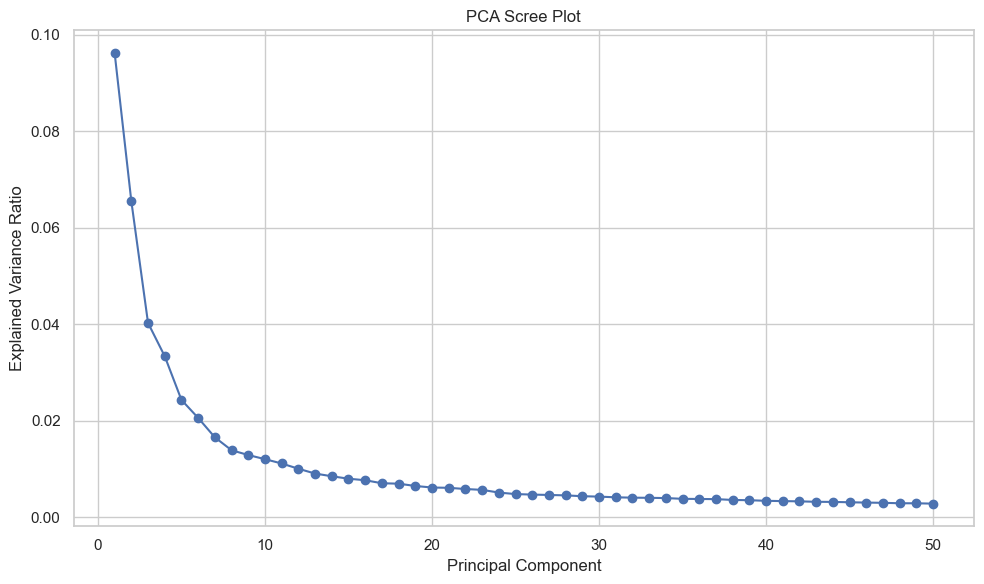

In [10]:
# =============================================================================
# Scree plot
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    explained_variance["PC"],
    explained_variance["explained_variance_ratio"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")

plt.tight_layout()
plt.show()

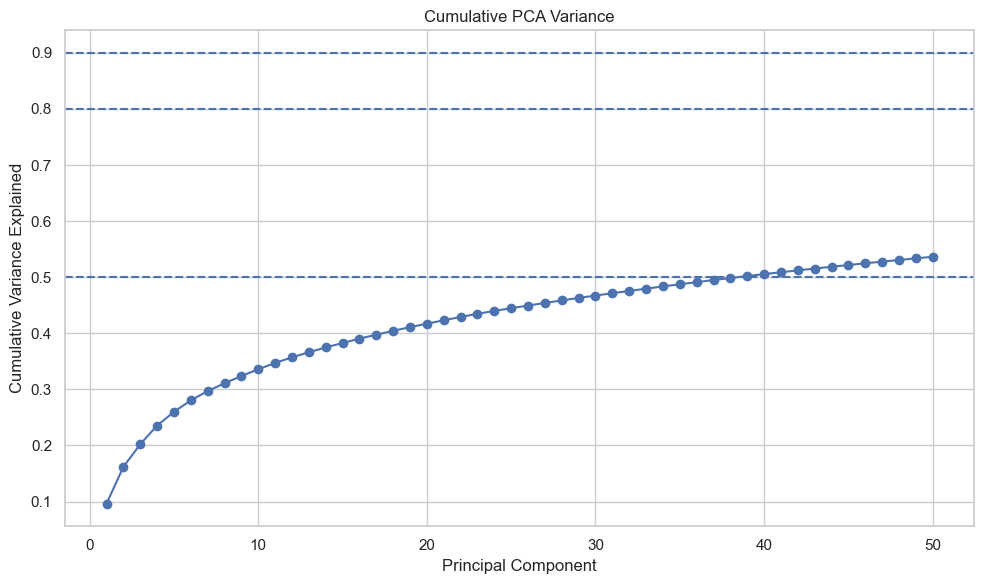

In [11]:
# =============================================================================
# Cumulative variance
# =============================================================================

plt.figure(figsize=(10, 6))

plt.plot(
    explained_variance["PC"],
    explained_variance["cumulative_variance_ratio"],
    marker="o"
)

plt.axhline(0.50, linestyle="--")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative PCA Variance")

plt.tight_layout()
plt.show()

### PCA Variance Structure Assessment

The transcriptomic variance of the integrated cohort is distributed across a large number of principal components.

The first principal component explains approximately 9.6% of total variance, while the first five components collectively explain approximately 26% of total variance. Fifty principal components capture approximately 54% of total transcriptomic variance, reflecting the high-dimensional nature of the integrated cohort.

These observations suggest that transcriptomic organization within the integrated cohort is not dominated by a single global factor. Instead, variation appears to be distributed across multiple partially independent sources.

This pattern is consistent with the biological and lineage heterogeneity expected in a multi-lineage pan-cancer cohort and motivates the use of multi-component representations in downstream exploratory analyses.

### PCA Visualization by Lineage

The first principal components are visualized to assess whether major transcriptomic axes are associated with tissue lineage.

If lineage is a dominant source of variation, samples originating from similar tissues are expected to cluster together within the low-dimensional PCA space.

This analysis is descriptive and intended to characterize global transcriptomic organization rather than infer biological mechanisms.

In [12]:
pca_df["OncotreeLineage"].nunique()

27

In [13]:
pca_df["OncotreeLineage"].value_counts().sort_values(
    ascending=False
)

OncotreeLineage
Lung                         136
Lymphoid                      86
Esophagus/Stomach             51
Breast                        47
Bowel                         43
Skin                          37
CNS/Brain                     37
Ovary/Fallopian Tube          34
Myeloid                       32
Pancreas                      28
Head and Neck                 26
Kidney                        19
Peripheral Nervous System     18
Bone                          17
Bladder/Urinary Tract         16
Uterus                        16
Thyroid                       13
Liver                         13
Cervix                        11
Soft Tissue                   11
Prostate                       7
Pleura                         7
Vulva/Vagina                   2
Biliary Tract                  2
Testis                         2
Fibroblast                     1
Adrenal Gland                  1
Name: count, dtype: int64

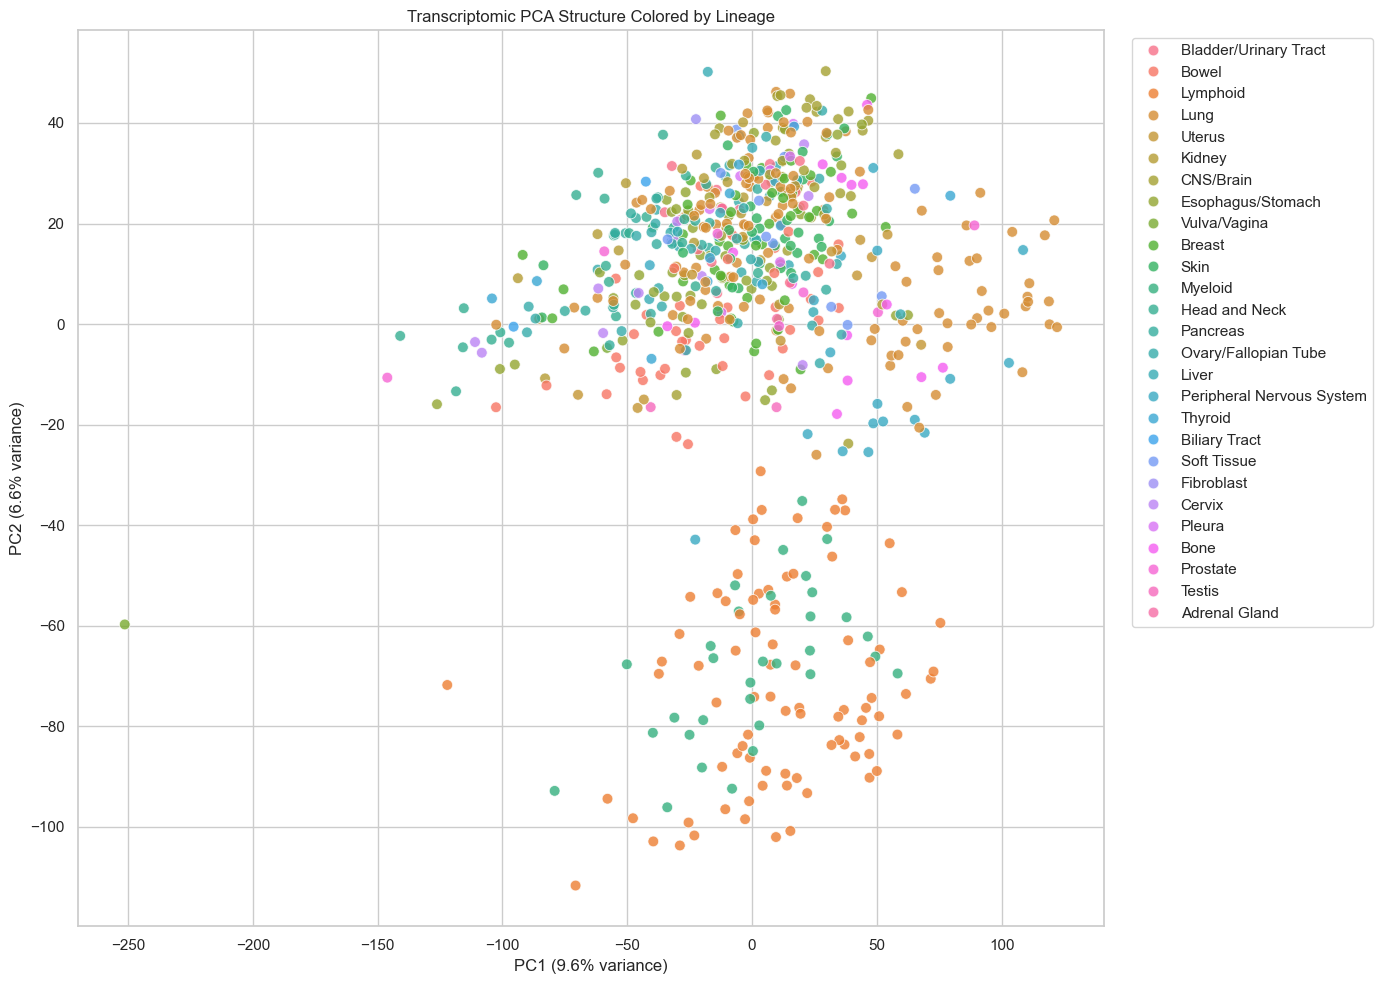

In [14]:
# =============================================================================
# PCA visualization by lineage
# =============================================================================

plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="OncotreeLineage",
    alpha=0.8,
    s=60
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)"
)

plt.title(
    "Transcriptomic PCA Structure Colored by Lineage"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

### Initial Lineage Structure Assessment

The PCA projection reveals evidence of lineage-associated organization within the transcriptomic space.

Several regions of the embedding appear enriched for specific lineages, indicating that tissue-of-origin contributes substantially to global transcriptomic variation. However, lineage-specific clusters are not completely separated, and substantial overlap remains across many regions of the PCA space.

These observations suggest that lineage is an important, but not exclusive, source of transcriptomic variation within the integrated cohort.

The presence of mixed-lineage regions indicates that additional biological processes beyond tissue-of-origin may contribute to the overall structure of the expression landscape.

Further evaluation using additional principal components is required before drawing conclusions regarding the relative contribution of lineage effects.

---

### Lineage Contribution to Principal Components

To quantify the extent to which lineage is associated with the major transcriptomic axes, each principal component is evaluated using a one-way ANOVA model with `OncotreeLineage` as the grouping variable.

For each component, eta-squared is computed as an effect-size estimate representing the fraction of component variance associated with lineage labels.

This analysis is descriptive and is used to assess lineage-associated structure, not to infer causality.

In [15]:
def compute_eta_squared(data, pc_col, group_col):
    """
    Compute eta-squared (η²) effect size for a principal component.

    Eta-squared is calculated as the proportion of total variance
    explained by differences between groups:

        η² = SS_between / SS_total

    In this notebook, η² quantifies the fraction of variance in a
    principal component that is associated with lineage labels.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataframe containing principal component scores and group labels.

    pc_col : str
        Name of the principal component column (e.g. "PC1").

    group_col : str
        Name of the grouping variable column
        (e.g. "OncotreeLineage").

    Returns
    -------
    float
        Eta-squared effect size ranging from 0 to 1.

        Values near 0 indicate little association between the principal
        component and the grouping variable.

        Values near 1 indicate that most of the component variance is
        associated with group membership.
    """
    overall_mean = data[pc_col].mean()

    ss_between = (
        data
        .groupby(group_col)[pc_col]
        .apply(lambda x: len(x) * (x.mean() - overall_mean) ** 2)
        .sum()
    )

    ss_total = ((data[pc_col] - overall_mean) ** 2).sum()

    return ss_between / ss_total

In [16]:
# =============================================================================
# Lineage contribution to principal components
# =============================================================================

lineage_effects = []

for pc in [f"PC{i}" for i in range(1, 51)]:
    eta_sq = compute_eta_squared(
        data=pca_df,
        pc_col=pc,
        group_col="OncotreeLineage"
    )

    lineage_effects.append({
        "PC": pc,
        "lineage_eta_squared": eta_sq,
        "pca_variance_ratio": explained_variance.loc[
            explained_variance["PC"] == int(pc.replace("PC", "")),
            "explained_variance_ratio"
        ].iloc[0],
        "cumulative_pca_variance_ratio": explained_variance.loc[
            explained_variance["PC"] == int(pc.replace("PC", "")),
            "cumulative_variance_ratio"
        ].iloc[0]
    })

lineage_effects_df = pd.DataFrame(lineage_effects)

lineage_effects_df.head(10)

,PC,lineage_eta_squared,pca_variance_ratio,cumulative_pca_variance_ratio
0,PC1,0.284091,0.096281,0.096281
1,PC2,0.831637,0.065533,0.161815
2,PC3,0.525525,0.040294,0.202109
3,PC4,0.370217,0.033396,0.235504
4,PC5,0.179694,0.024342,0.259846
5,PC6,0.216719,0.020609,0.280455
6,PC7,0.341731,0.016584,0.297039
7,PC8,0.468982,0.013906,0.310945
8,PC9,0.326736,0.012912,0.323857
9,PC10,0.565445,0.012056,0.335913


In [17]:
# =============================================================================
# Top lineage-associated PCs
# =============================================================================

lineage_effects_df.sort_values(
    "lineage_eta_squared",
    ascending=False
).head(15)

,PC,lineage_eta_squared,pca_variance_ratio,cumulative_pca_variance_ratio
1,PC2,0.831637,0.065533,0.161815
9,PC10,0.565445,0.012056,0.335913
2,PC3,0.525525,0.040294,0.202109
7,PC8,0.468982,0.013906,0.310945
10,PC11,0.427302,0.011160,0.347072
12,PC13,0.402116,0.009073,0.366214
3,PC4,0.370217,0.033396,0.235504
6,PC7,0.341731,0.016584,0.297039
15,PC16,0.337010,0.007685,0.390415
8,PC9,0.326736,0.012912,0.323857


In [18]:
# =============================================================================
# Compare lineage association with PCA variance explained
# =============================================================================

lineage_effects_df[
    ["PC", "lineage_eta_squared", "pca_variance_ratio"]
].head(15)

,PC,lineage_eta_squared,pca_variance_ratio
0,PC1,0.284091,0.096281
1,PC2,0.831637,0.065533
2,PC3,0.525525,0.040294
3,PC4,0.370217,0.033396
4,PC5,0.179694,0.024342
5,PC6,0.216719,0.020609
6,PC7,0.341731,0.016584
7,PC8,0.468982,0.013906
8,PC9,0.326736,0.012912
9,PC10,0.565445,0.012056


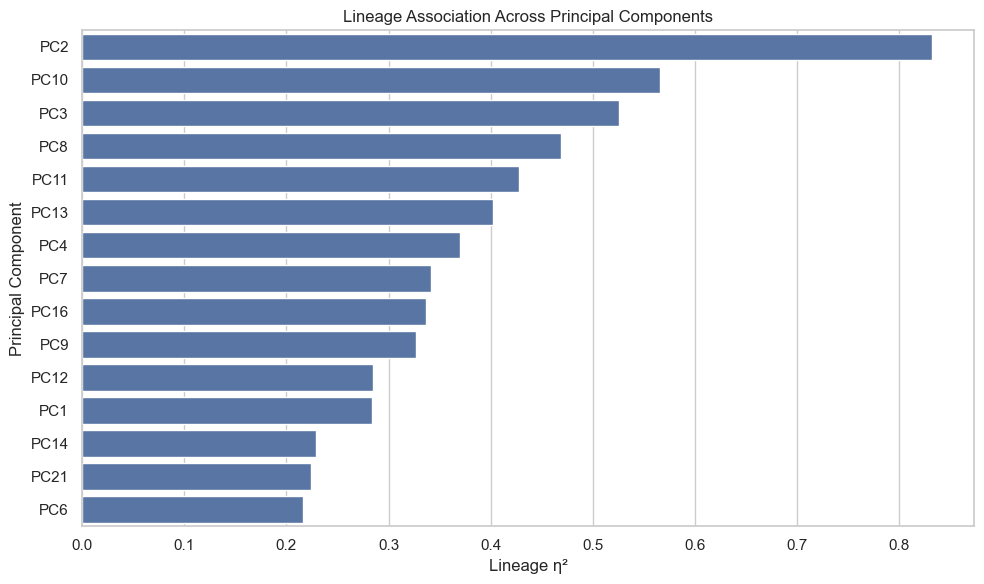

In [19]:
# =============================================================================
# Lineage association vs PCA variance plot
# ============================================================================= 

top_lineage_pcs = (
    lineage_effects_df
    .sort_values("lineage_eta_squared", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_lineage_pcs,
    x="lineage_eta_squared",
    y="PC"
)

plt.xlabel("Lineage η²")
plt.ylabel("Principal Component")
plt.title("Lineage Association Across Principal Components")

plt.tight_layout()
plt.show()

### Global Contribution of Lineage to PCA Structure

To estimate the overall contribution of lineage to transcriptomic organization, the lineage effect size of each principal component is weighted by the proportion of variance explained by that component.

This metric provides a summary estimate of the fraction of PCA variance associated with lineage effects within the analyzed PCA representation.

In [20]:
# =============================================================================
# Global lineage contribution
# =============================================================================

lineage_effects_df["weighted_lineage_variance"] = (
    lineage_effects_df["lineage_eta_squared"]
    * lineage_effects_df["pca_variance_ratio"]
)

global_lineage_contribution = (
    lineage_effects_df["weighted_lineage_variance"].sum()
)

total_pca_variance = (
    lineage_effects_df["pca_variance_ratio"].sum()
)

relative_lineage_contribution = (
    global_lineage_contribution
    / total_pca_variance
)

print(
    f"Variance captured by PCA representation: "
    f"{total_pca_variance:.3f}"
)

print(
    f"Lineage-associated variance within PCA representation: "
    f"{global_lineage_contribution:.3f}"
)

print(
    f"Relative lineage contribution: "
    f"{relative_lineage_contribution:.1%}"
)

Variance captured by PCA representation: 0.536
Lineage-associated variance within PCA representation: 0.182
Relative lineage contribution: 33.9%


### PCA Summary

The PCA analysis revealed a high-dimensional transcriptomic structure distributed across a large number of principal components.

Although lineage-associated organization was evident in both visual and quantitative analyses, lineage effects did not fully dominate the PCA representation.

Within the 50-component PCA space, approximately 33.9% of the captured variance was associated with lineage labels, indicating that tissue-of-origin constitutes an important but incomplete source of transcriptomic variation.

These observations suggest that additional biological processes beyond lineage contribute substantially to the global organization of the integrated transcriptomic landscape.

The presence of both lineage-associated and lineage-independent structure supports the continued exploration of recurrent transcriptomic programs in subsequent analyses.

---

## UMAP Analysis

UMAP is applied to the 50-component PCA representation to visualize non-linear transcriptomic structure across the integrated cohort.

This analysis is exploratory and is used to assess whether lineage-associated and mixed-lineage regions observed in PCA are also reflected in a non-linear embedding.

In [21]:
# =============================================================================
# UMAP embedding
# =============================================================================

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.3,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1
)

umap_embedding = umap_model.fit_transform(pca_scores)

umap_df = pd.DataFrame(
    umap_embedding,
    columns=["UMAP1", "UMAP2"]
)

umap_df["ModelID"] = pca_df["ModelID"]

umap_df = umap_df.merge(
    cohort_df[
        [
            "ModelID",
            "OncotreeLineage",
            "OncotreePrimaryDisease"
        ]
    ],
    on="ModelID",
    how="left"
)

umap_df.head()

,UMAP1,UMAP2,ModelID,OncotreeLineage,OncotreePrimaryDisease
0,8.332672,11.403283,ACH-000242,Bladder/Urinary Tract,Bladder Urothelial Carcinoma
1,8.884487,14.170609,ACH-000708,Bowel,Colorectal Adenocarcinoma
2,-5.264986,1.661659,ACH-000233,Lymphoid,Mature T and NK Neoplasms
3,9.012770,10.581618,ACH-000528,Lung,Non-Small Cell Lung Cancer
4,7.886219,8.796239,ACH-001655,Uterus,Uterine Sarcoma/Mesenchymal


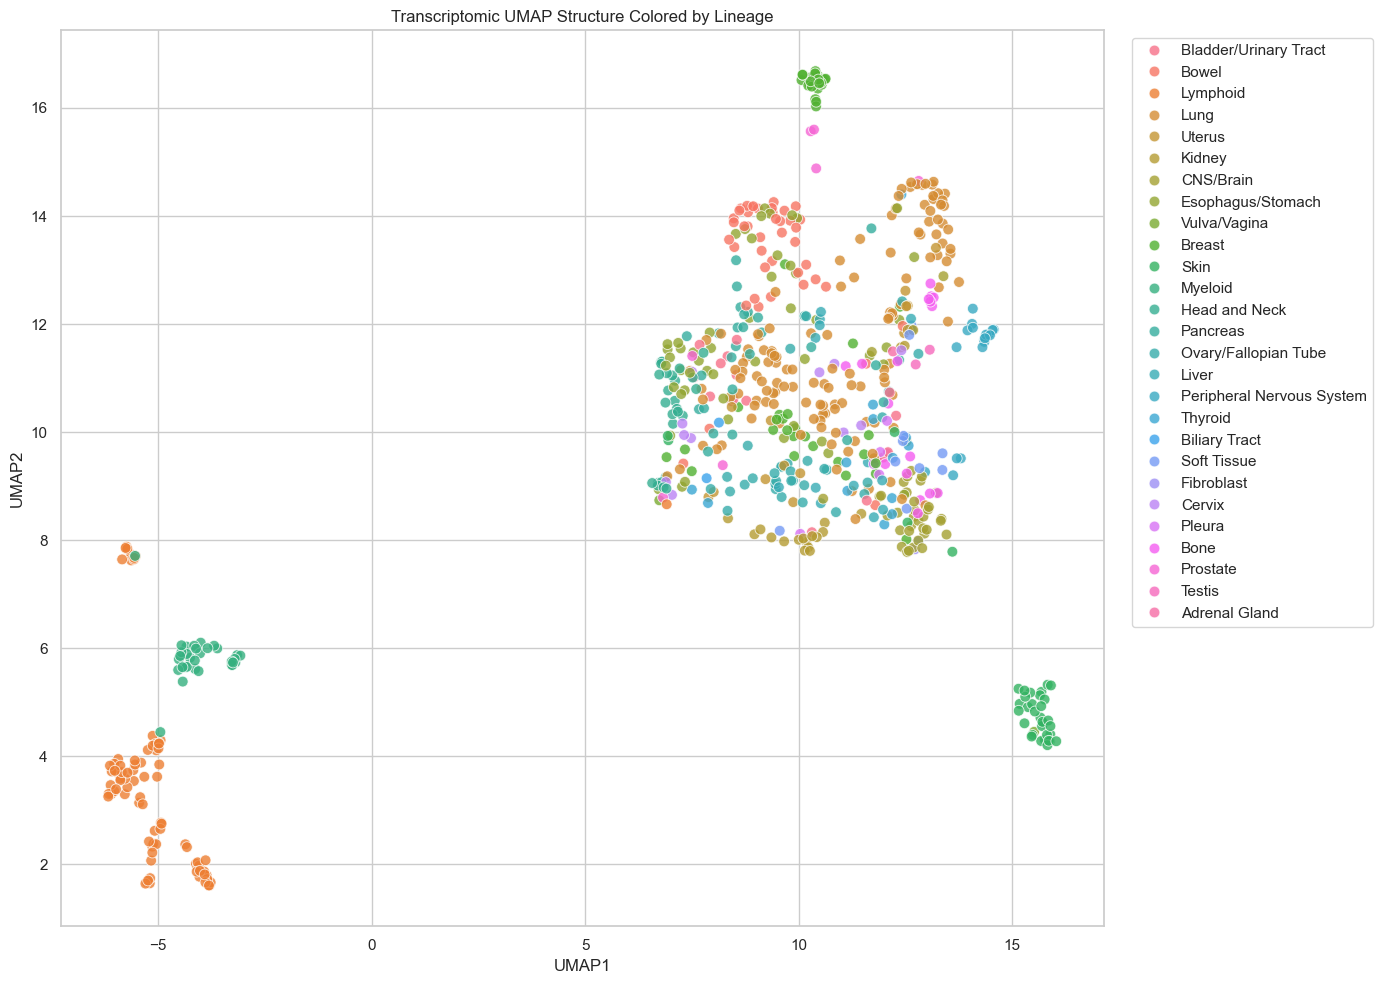

In [22]:
# =============================================================================
# UMAP visualization by lineage
# =============================================================================

plt.figure(figsize=(14, 10))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="OncotreeLineage",
    alpha=0.8,
    s=60
)

plt.title(
    "Transcriptomic UMAP Structure Colored by Lineage"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [23]:
pca_df["OncotreeLineage"].value_counts().head(10)

OncotreeLineage
Lung                    136
Lymphoid                 86
Esophagus/Stomach        51
Breast                   47
Bowel                    43
Skin                     37
CNS/Brain                37
Ovary/Fallopian Tube     34
Myeloid                  32
Pancreas                 28
Name: count, dtype: int64

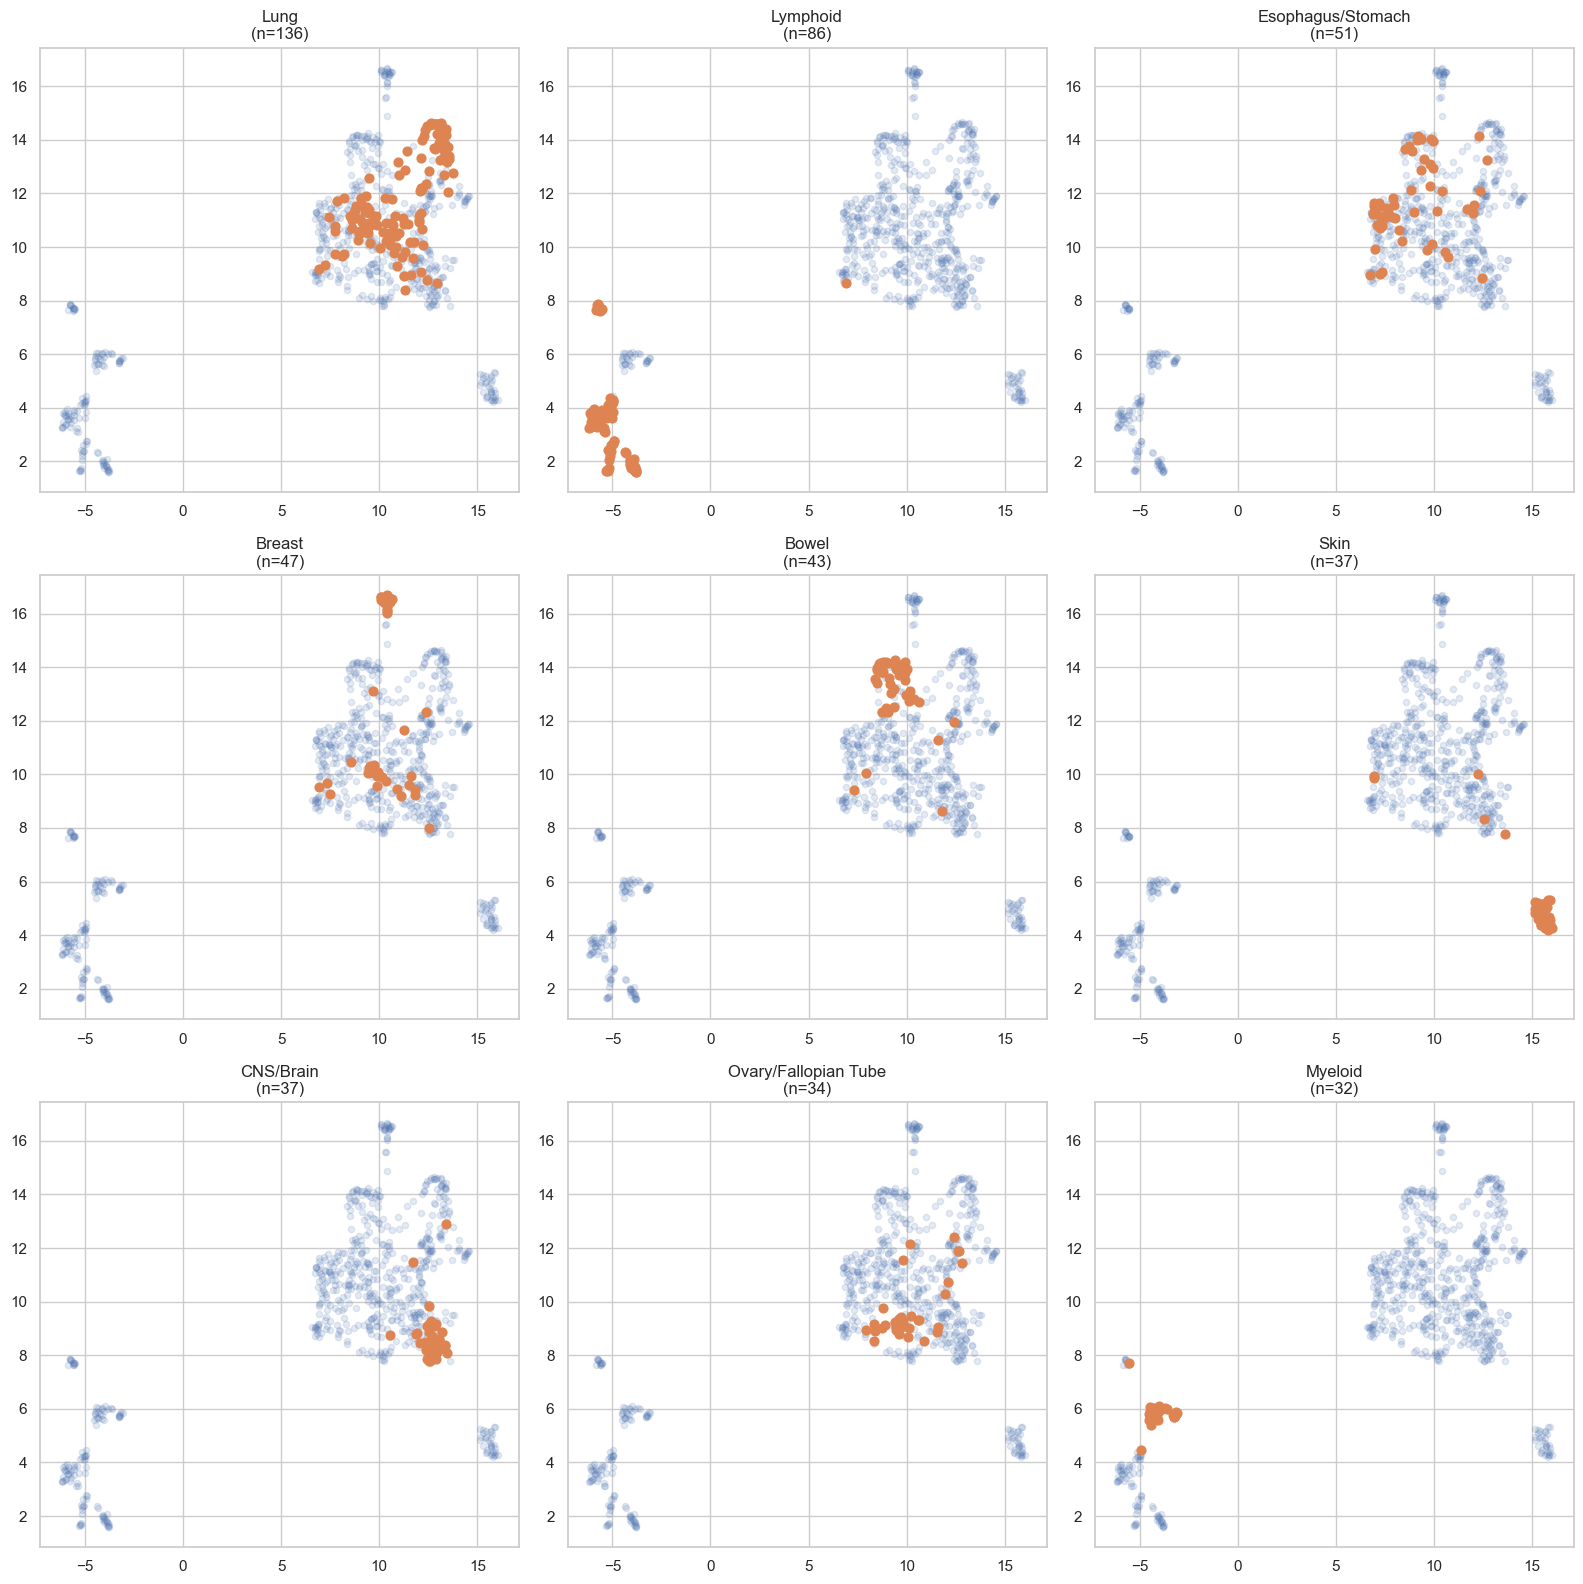

In [24]:
# =============================================================================
# UMAP lineage localization
# =============================================================================

top_lineages = (
    umap_df["OncotreeLineage"]
    .value_counts()
    .head(9)
    .index
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 16)
)

axes = axes.flatten()

for ax, lineage in zip(axes, top_lineages):

    background = (
        umap_df["OncotreeLineage"] != lineage
    )

    ax.scatter(
        umap_df.loc[background, "UMAP1"],
        umap_df.loc[background, "UMAP2"],
        alpha=0.15,
        s=20
    )

    highlight = (
        umap_df["OncotreeLineage"] == lineage
    )

    ax.scatter(
        umap_df.loc[highlight, "UMAP1"],
        umap_df.loc[highlight, "UMAP2"],
        s=40
    )

    ax.set_title(
        f"{lineage}\n(n={highlight.sum()})"
    )

plt.tight_layout()
plt.show()

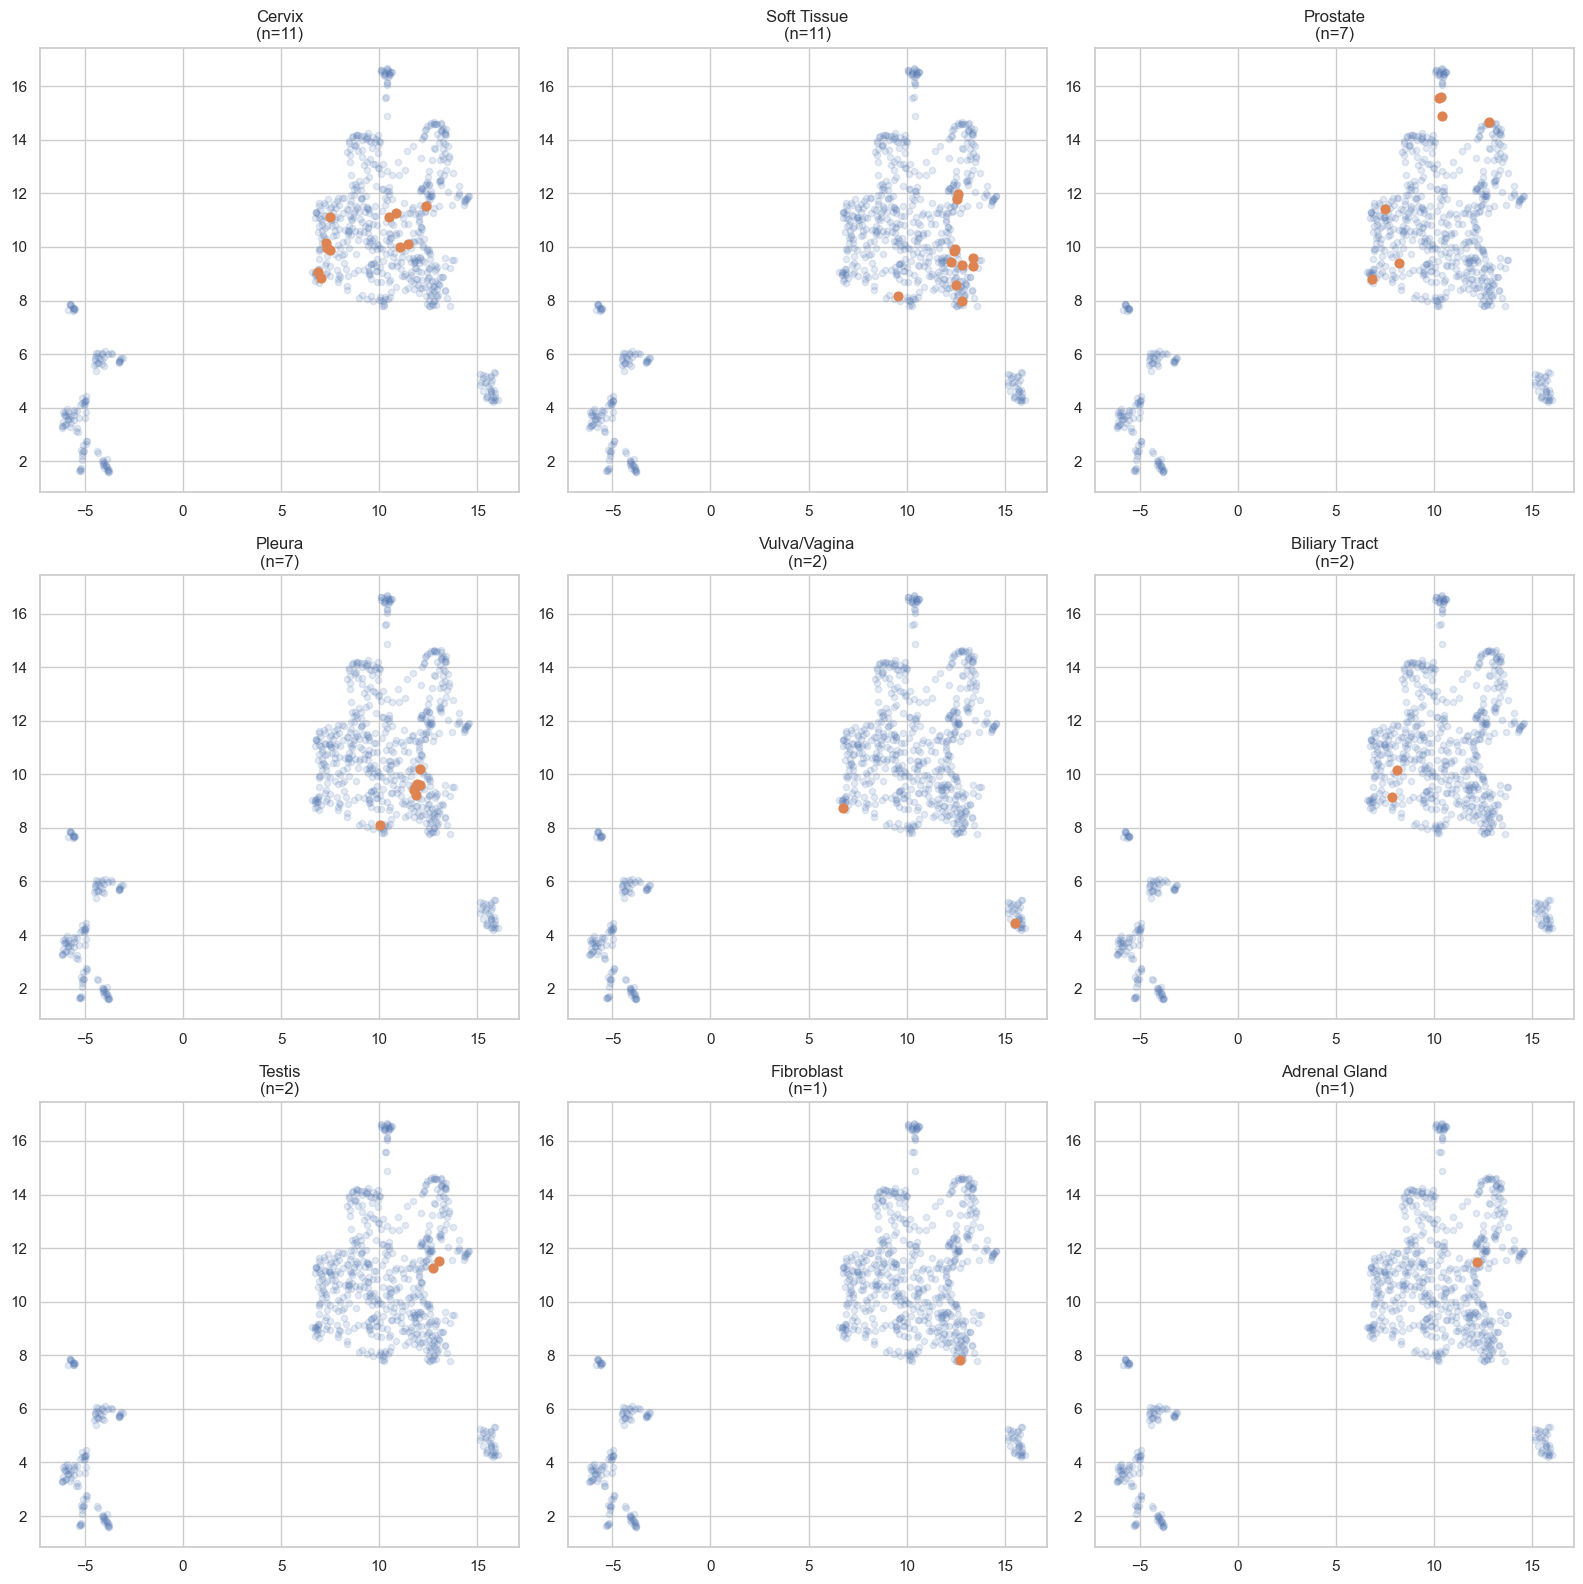

In [25]:
# =============================================================================
# UMAP localization - least abundant lineages
# =============================================================================

bottom_lineages = (
    umap_df["OncotreeLineage"]
    .value_counts()
    .tail(9)
    .index
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 16)
)

axes = axes.flatten()

for ax, lineage in zip(axes, bottom_lineages):

    background = (
        umap_df["OncotreeLineage"] != lineage
    )

    ax.scatter(
        umap_df.loc[background, "UMAP1"],
        umap_df.loc[background, "UMAP2"],
        alpha=0.15,
        s=20
    )

    highlight = (
        umap_df["OncotreeLineage"] == lineage
    )

    ax.scatter(
        umap_df.loc[highlight, "UMAP1"],
        umap_df.loc[highlight, "UMAP2"],
        s=40
    )

    ax.set_title(
        f"{lineage}\n(n={highlight.sum()})"
    )

plt.tight_layout()
plt.show()

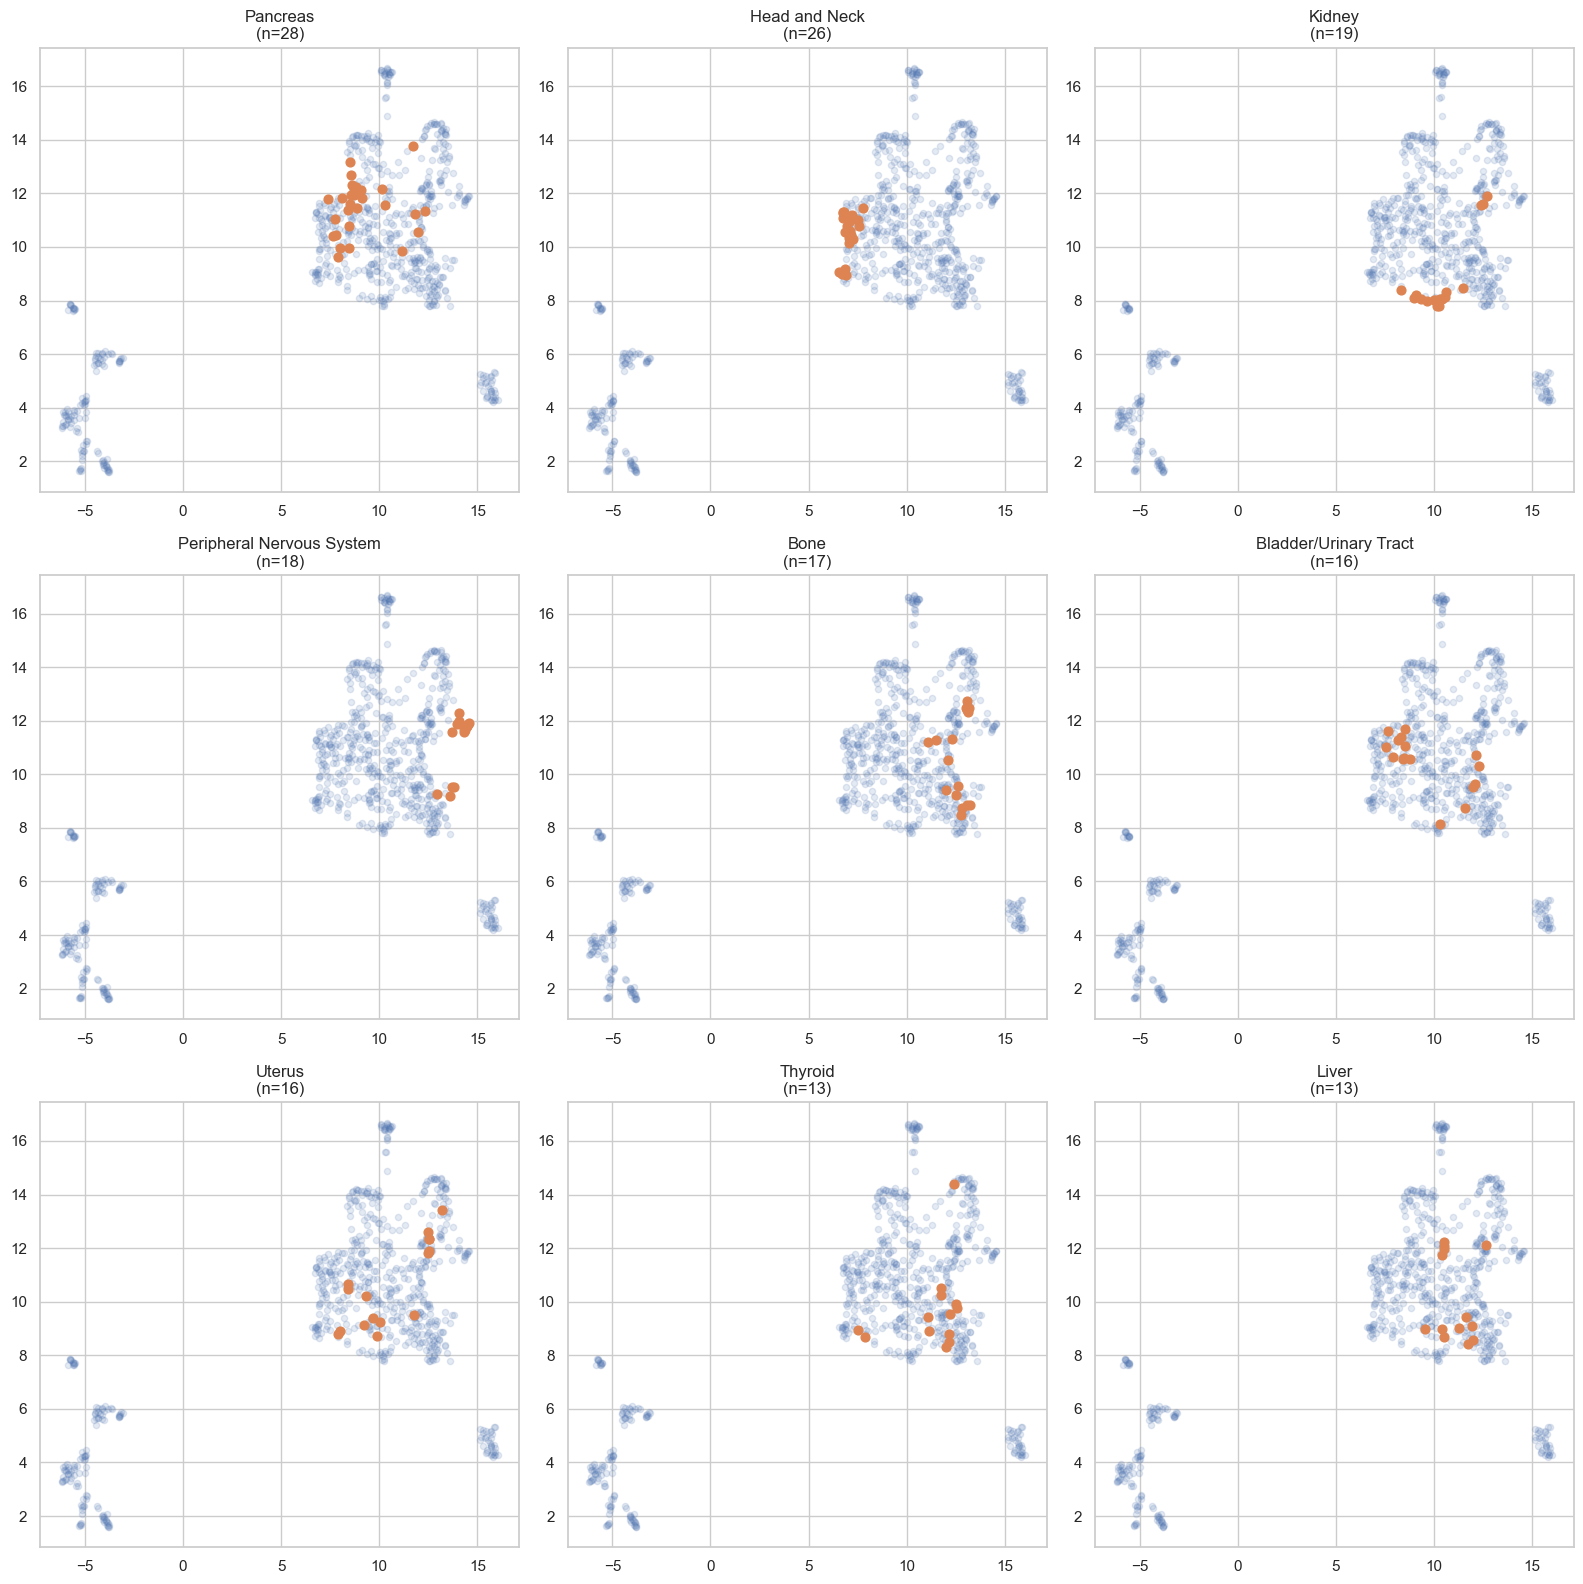

In [26]:
# =============================================================================
# UMAP localization - intermediate-frequency lineages
# =============================================================================

intermediate_lineages = [
    "Pancreas",
    "Head and Neck",
    "Kidney",
    "Peripheral Nervous System",
    "Bone",
    "Bladder/Urinary Tract",
    "Uterus",
    "Thyroid",
    "Liver"
]

fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 16)
)

axes = axes.flatten()

for ax, lineage in zip(axes, intermediate_lineages):

    background = (
        umap_df["OncotreeLineage"] != lineage
    )

    ax.scatter(
        umap_df.loc[background, "UMAP1"],
        umap_df.loc[background, "UMAP2"],
        alpha=0.15,
        s=20
    )

    highlight = (
        umap_df["OncotreeLineage"] == lineage
    )

    ax.scatter(
        umap_df.loc[highlight, "UMAP1"],
        umap_df.loc[highlight, "UMAP2"],
        s=40
    )

    ax.set_title(
        f"{lineage}\n(n={highlight.sum()})"
    )

plt.tight_layout()
plt.show()

### UMAP Summary

The UMAP embedding revealed a combination of lineage-associated regions and shared transcriptomic space across the integrated cohort.

Several lineages occupied preferential regions of the embedding, particularly hematopoietic lineages and selected solid-tumor groups, indicating that tissue-of-origin contributes to local transcriptomic organization. However, lineage-specific regions did not fully partition the transcriptomic landscape.

A large central component of the embedding contained substantial overlap among multiple lineages, suggesting the presence of transcriptomic structure that is not exclusively explained by tissue-of-origin.

Inspection of both highly represented and intermediate-frequency lineages revealed a mixture of lineage-enriched regions and shared embedding neighborhoods. These observations are consistent with the PCA-based lineage analyses, which indicated that lineage represents an important but incomplete contributor to global transcriptomic variation.

Overall, the UMAP analysis supports a model in which lineage-associated and lineage-independent sources of variation jointly contribute to the organization of the integrated transcriptomic space.

---

## Exploratory Clustering Assessment

To further characterize transcriptomic organization, unsupervised clustering is applied to the reduced transcriptomic representation.

The objective is not to define biological states or transcriptomic programs, but rather to assess whether recurrent structural groupings emerge within the integrated cohort and to evaluate their relationship with lineage labels.

Particular attention is given to determining whether identified clusters are predominantly lineage-driven or whether mixed-lineage structures emerge within the transcriptomic landscape.

### HDBSCAN Clustering

Hierarchical Density-Based Spatial Clustering (HDBSCAN) is applied to the PCA representation to identify recurrent transcriptomic groupings within the integrated cohort.

Unlike partition-based methods, HDBSCAN does not require specification of the number of clusters and can identify samples that do not belong to any stable cluster.

The objective is exploratory and focuses on characterizing the structural organization of the transcriptomic space rather than defining biological states.

In [27]:
# =============================================================================
# HDBSCAN clustering
# =============================================================================

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=10
)

cluster_labels = clusterer.fit_predict(
    pca_scores
)

pca_df["Cluster"] = cluster_labels
umap_df["Cluster"] = cluster_labels

print(
    f"Clusters detected: "
    f"{len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)}"
)

print(
    f"Noise samples: "
    f"{(cluster_labels == -1).sum()}"
)

Clusters detected: 2
Noise samples: 150


In [28]:
pd.Series(cluster_labels).value_counts().sort_index()

-1    150
 0     78
 1    485
Name: count, dtype: int64

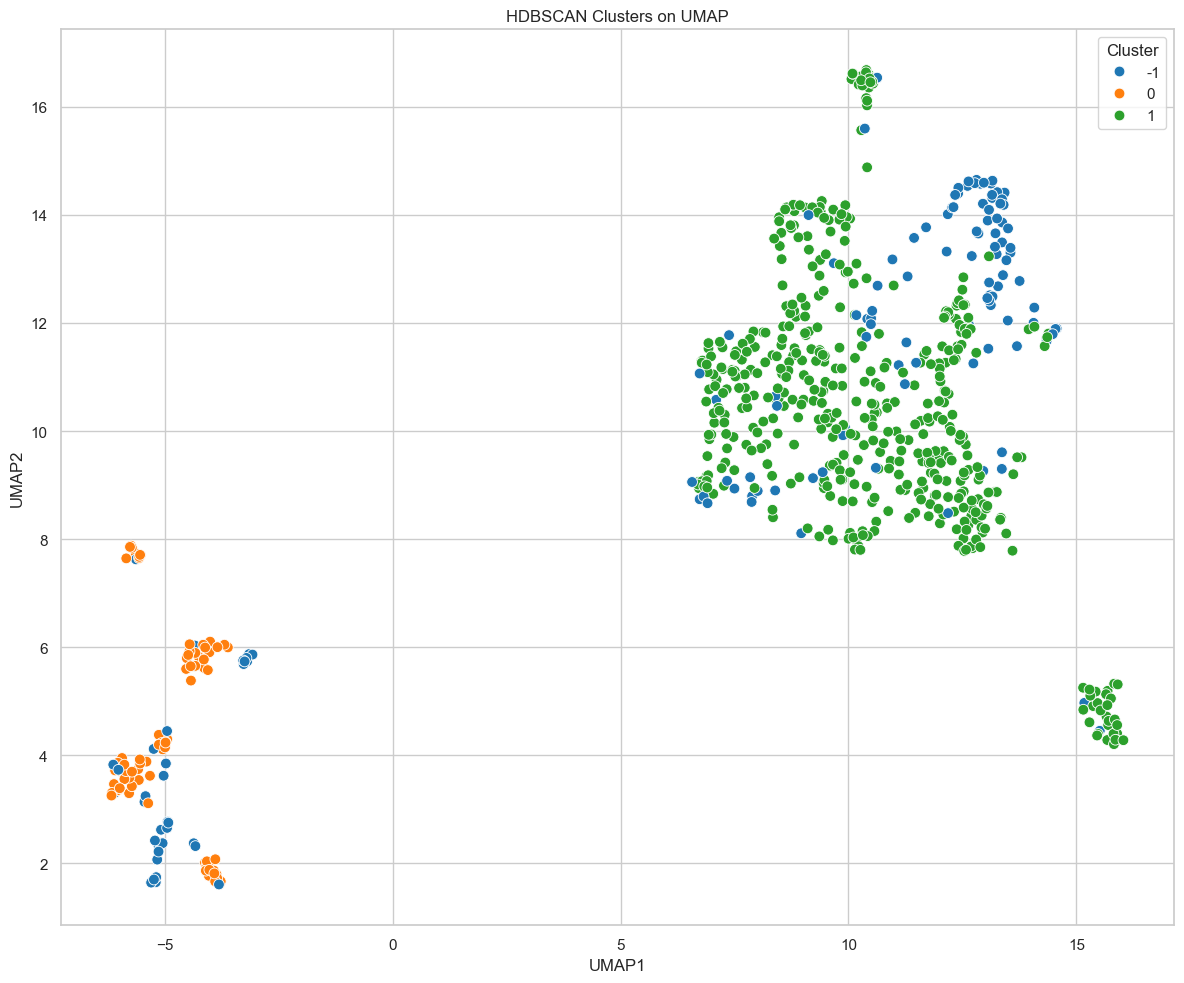

In [29]:
plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title("HDBSCAN Clusters on UMAP")

plt.tight_layout()
plt.show()

In [30]:
# =============================================================================
# HDBSCAN sensitivity analysis
# =============================================================================

sensitivity_results = []

for min_cluster_size in [10, 15, 20]:

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=10
    )

    labels = clusterer.fit_predict(pca_scores)

    n_clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    n_noise = (labels == -1).sum()

    sensitivity_results.append({
        "min_cluster_size": min_cluster_size,
        "min_samples": 10,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_fraction": n_noise / len(labels)
    })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df

,min_cluster_size,min_samples,n_clusters,n_noise,noise_fraction
0,10,10,4,144,0.201964
1,15,10,4,144,0.201964
2,20,10,2,150,0.210379


In [31]:
min_cluster_size = 15
min_samples = 10

In [32]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=10
)

cluster_labels = clusterer.fit_predict(
    pca_scores
)

pca_df["Cluster"] = cluster_labels
umap_df["Cluster"] = cluster_labels

In [33]:
pd.Series(cluster_labels).value_counts().sort_index()

-1    144
 0     15
 1    485
 2     15
 3     54
Name: count, dtype: int64

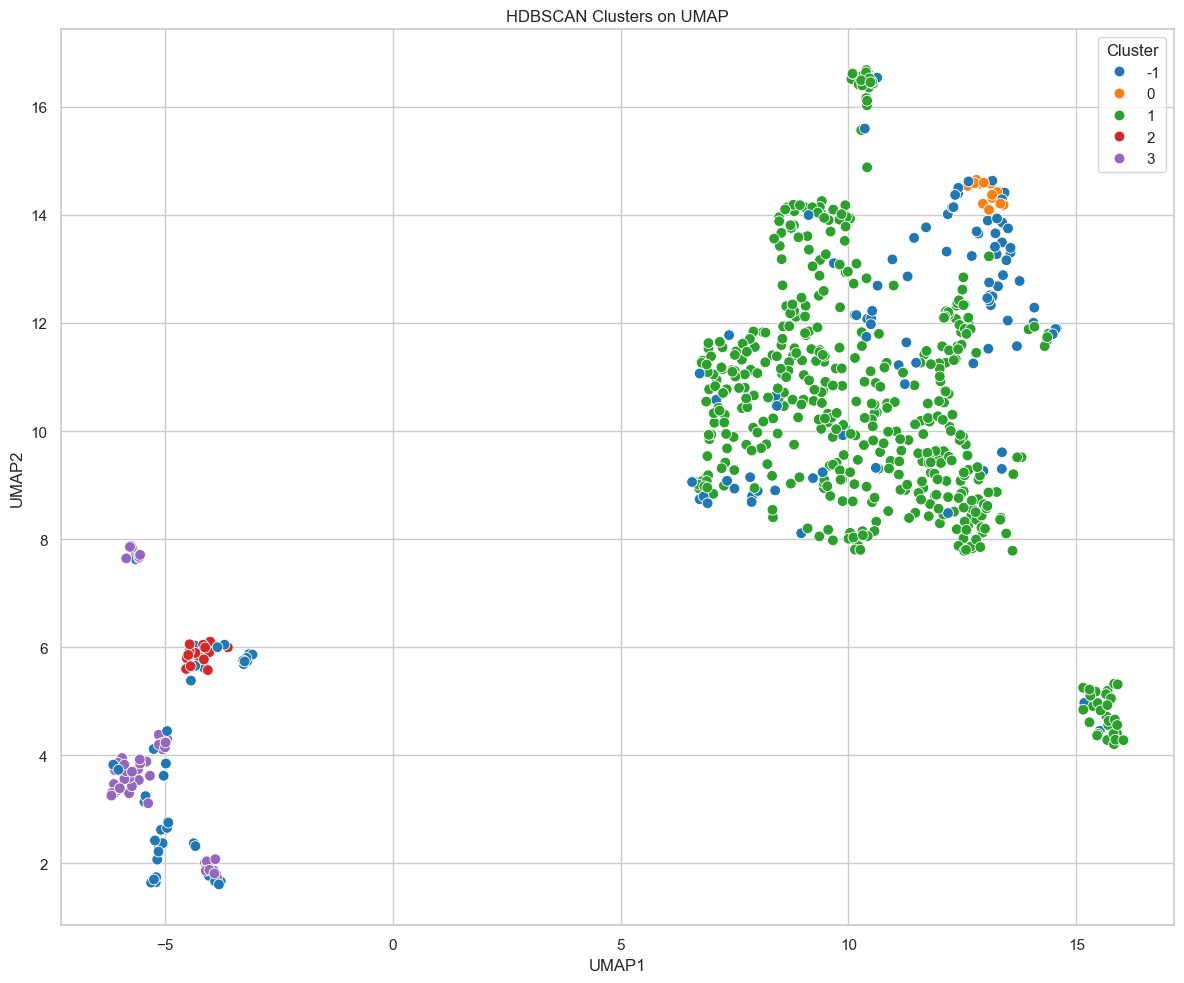

In [34]:
# =============================================================================
# HDBSCAN clusters on UMAP
# =============================================================================

plt.figure(figsize=(12, 10))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title(
    "HDBSCAN Clusters on UMAP"
)

plt.tight_layout()
plt.show()

In [35]:
# =============================================================================
# Cluster composition
# =============================================================================

pd.crosstab(
    pca_df["Cluster"],
    pca_df["OncotreeLineage"]
)

OncotreeLineage,Adrenal Gland,Biliary Tract,Bladder/Urinary Tract,Bone,Bowel,Breast,CNS/Brain,Cervix,Esophagus/Stomach,Fibroblast,...,Pancreas,Peripheral Nervous System,Pleura,Prostate,Skin,Soft Tissue,Testis,Thyroid,Uterus,Vulva/Vagina
Cluster,,,,,,,,,,,,,,,,,,,,,
-1,0,1,0,8,1,6,1,0,5,0,...,2,10,0,2,1,3,2,4,6,2
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1,1,16,9,42,41,36,11,46,1,...,26,8,7,4,36,8,0,9,10,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [36]:
pd.set_option("display.max_columns", None)

pd.crosstab(
    pca_df["Cluster"],
    pca_df["OncotreeLineage"]
)

OncotreeLineage,Adrenal Gland,Biliary Tract,Bladder/Urinary Tract,Bone,Bowel,Breast,CNS/Brain,Cervix,Esophagus/Stomach,Fibroblast,Head and Neck,Kidney,Liver,Lung,Lymphoid,Myeloid,Ovary/Fallopian Tube,Pancreas,Peripheral Nervous System,Pleura,Prostate,Skin,Soft Tissue,Testis,Thyroid,Uterus,Vulva/Vagina
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
-1,0,1,0,8,1,6,1,0,5,0,3,1,4,29,33,16,4,2,10,0,2,1,3,2,4,6,2
0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,0,0,1,0,0,0,0,0,0
1,1,1,16,9,42,41,36,11,46,1,23,18,9,93,0,0,30,26,8,7,4,36,8,0,9,10,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,53,1,0,0,0,0,0,0,0,0,0,0,0


### HDBSCAN Summary

HDBSCAN clustering identified a small number of highly stable transcriptomic groupings within the integrated cohort.

Two clusters corresponded almost exclusively to hematopoietic lineages, with separate clusters enriched for Lymphoid and Myeloid models. An additional small cluster captured a distinct subset of lung-derived cell lines. These findings indicate that certain lineage-associated transcriptomic structures are sufficiently strong to emerge as stable density-based clusters.

However, the majority of samples were assigned to a large mixed-lineage cluster containing representatives from numerous tissue origins. This dominant cluster included models from a broad range of solid-tumor lineages and did not exhibit clear lineage exclusivity.

Approximately 20% of samples were classified as noise by HDBSCAN, suggesting the presence of transitional, heterogeneous, or less densely populated regions of transcriptomic space that could not be assigned confidently to a stable cluster.

Overall, the clustering results support the conclusions obtained from PCA and UMAP analyses. While lineage contributes substantially to transcriptomic organization, a large fraction of the integrated cohort occupies shared transcriptomic space that is not partitioned exclusively by tissue-of-origin.

---

## Notebook Summary

The integrated transcriptomic cohort exhibits a high-dimensional structure shaped by both lineage-associated and lineage-independent sources of variation.

PCA analyses indicated that lineage contributes substantially to transcriptomic organization but does not fully dominate the expression landscape. UMAP visualizations revealed a combination of lineage-enriched regions and shared transcriptomic space across multiple tissue origins.

Density-based clustering identified a limited number of stable lineage-enriched groups, primarily among hematopoietic lineages, while the majority of samples occupied a large mixed-lineage transcriptomic component.

Overall, these results support the presence of both lineage-specific and cross-lineage transcriptomic structure within the integrated cohort and provide a foundation for downstream program-discovery analyses.